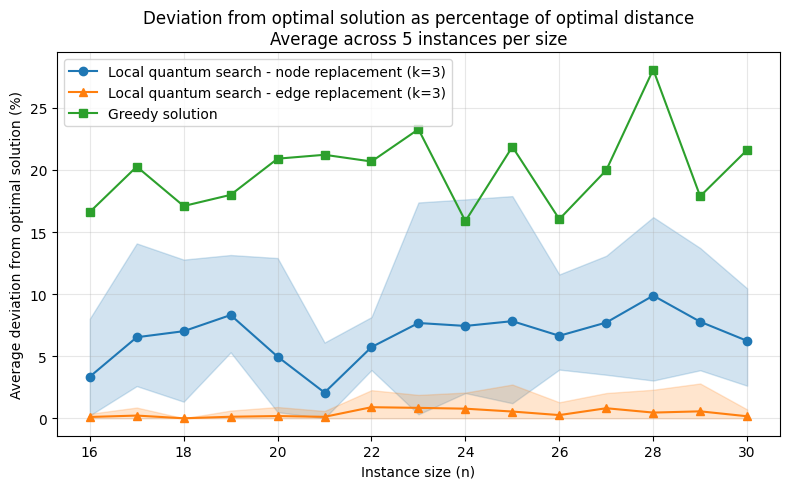

In [13]:
import json
import numpy as np
import os
import matplotlib.pyplot as plt

opt_values_path = os.path.join("data", "opt_values.json")
if not os.path.exists(opt_values_path):
    opt_values_path = os.path.join("data", "tsp_opt_values.json")

with open(opt_values_path, "r", encoding="utf-8") as f:
    opt_values = json.load(f)

with open(os.path.join("results", "tsp_results_node_replacement.json"), "r", encoding="utf-8") as f:
    nr = json.load(f)

with open(os.path.join("results", "tsp_results_3-opt.json"), "r", encoding="utf-8") as f:
    solutions_3opt = json.load(f)

# JSON keys are strings; normalize to ints
opt_values    = {int(n): {int(i): v for i, v in opts.items()} for n, opts in opt_values.items()}
nr            = {int(n): {int(k): {int(i): v for i, v in inst.items()} for k, inst in ks.items()} for n, ks in nr.items()}
solutions_3opt = {int(n): {int(i): v for i, v in sols.items()} for n, sols in solutions_3opt.items()}

K_NODE = 3  # number of replaced nodes to show

sizes = sorted(opt_values.keys())
avg_dev_pct = []
avg_greedy_dev_pct = []
avg_dev_3opt_pct = []
min_dev_pct = []
max_dev_pct = []
min_dev_3opt_pct = []
max_dev_3opt_pct = []

for n in sizes:
    devs = []
    greedy_devs = []
    devs_3opt = []
    for i, opt in opt_values[n].items():
        # node-replacement k=3
        if n in nr and K_NODE in nr[n] and i in nr[n][K_NODE]:
            devs.append((nr[n][K_NODE][i]["val"] / opt - 1.0) * 100.0)
            greedy_devs.append((nr[n][K_NODE][i]["greedy_val"] / opt - 1.0) * 100.0)
        # 3-opt edge replacement
        if n in solutions_3opt and i in solutions_3opt[n]:
            devs_3opt.append((solutions_3opt[n][i]["val"] / opt - 1.0) * 100.0)

    avg_dev_pct.append(sum(devs) / len(devs) if devs else None)
    avg_greedy_dev_pct.append(sum(greedy_devs) / len(greedy_devs) if greedy_devs else None)
    min_dev_pct.append(min(devs) if devs else None)
    max_dev_pct.append(max(devs) if devs else None)

    if devs_3opt:
        avg_dev_3opt_pct.append(sum(devs_3opt) / len(devs_3opt))
        min_dev_3opt_pct.append(min(devs_3opt))
        max_dev_3opt_pct.append(max(devs_3opt))
    else:
        avg_dev_3opt_pct.append(None)
        min_dev_3opt_pct.append(None)
        max_dev_3opt_pct.append(None)

# Filter out sizes with missing data
sizes_nr     = [n for n, v in zip(sizes, avg_dev_pct) if v is not None]
avg_nr       = [v for v in avg_dev_pct if v is not None]
min_nr       = [v for v in min_dev_pct if v is not None]
max_nr       = [v for v in max_dev_pct if v is not None]
sizes_greedy = [n for n, v in zip(sizes, avg_greedy_dev_pct) if v is not None]
avg_greedy   = [v for v in avg_greedy_dev_pct if v is not None]

sizes_3opt             = [n for n, v in zip(sizes, avg_dev_3opt_pct) if v is not None]
avg_dev_3opt_filtered  = [v for v in avg_dev_3opt_pct if v is not None]
min_dev_3opt_filtered  = [v for v in min_dev_3opt_pct if v is not None]
max_dev_3opt_filtered  = [v for v in max_dev_3opt_pct if v is not None]

plt.figure(figsize=(8, 5))
plt.plot(sizes_nr, avg_nr, marker="o", color="tab:blue", label=f"Local quantum search - node replacement (k={K_NODE})")
plt.fill_between(sizes_nr, min_nr, max_nr, color="tab:blue", alpha=0.2)
plt.plot(sizes_3opt, avg_dev_3opt_filtered, marker="^", color="tab:orange", label="Local quantum search - edge replacement (k=3)")
plt.plot(sizes_greedy, avg_greedy, marker="s", color="tab:green", label="Greedy solution")

plt.fill_between(sizes_3opt, min_dev_3opt_filtered, max_dev_3opt_filtered, color="tab:orange", alpha=0.2)
plt.xlabel("Instance size (n)")
plt.ylabel("Average deviation from optimal solution (%)")
plt.title("Deviation from optimal solution as percentage of optimal distance\nAverage across 5 instances per size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("results/approximation_tsp.pdf")
plt.show()


In [2]:
def g(x):
    return 0.14*x**2 + 7.7*x

def g_inv(x):
    return (-7.7 + (7.7**2 + 4*0.14*x)**0.5) / (2*0.14)


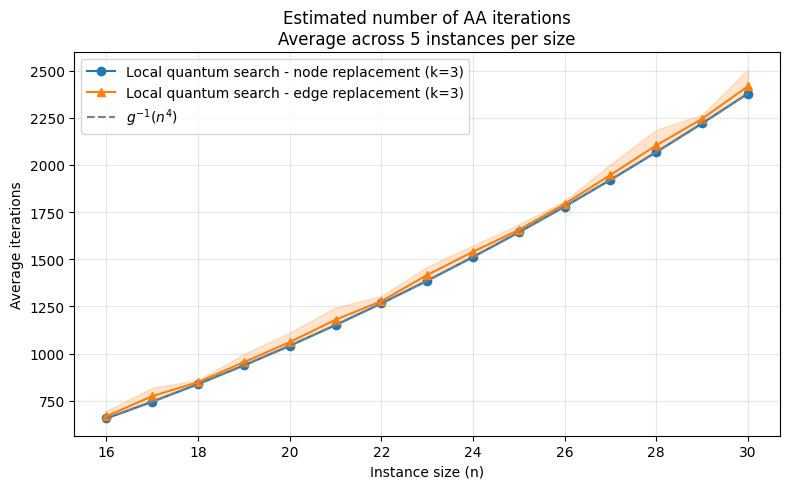

In [15]:
avg_iterations = []
avg_iterations_3opt = []
min_iterations = []
max_iterations = []
min_iterations_3opt = []
max_iterations_3opt = []

for n in sizes:
    iterations = []
    iterations_3opt = []
    for i in opt_values[n]:
        # node-replacement k=K_NODE
        if n in nr and K_NODE in nr[n] and i in nr[n][K_NODE] and "iterations" in nr[n][K_NODE][i]:
            iterations.append(g_inv(nr[n][K_NODE][i]["iterations"]))
        # 3-opt edge replacement
        if n in solutions_3opt and i in solutions_3opt[n] and "iterations" in solutions_3opt[n][i]:
            iterations_3opt.append(g_inv(solutions_3opt[n][i]["iterations"]))

    avg_iterations.append(sum(iterations) / len(iterations) if iterations else None)
    min_iterations.append(min(iterations) if iterations else None)
    max_iterations.append(max(iterations) if iterations else None)

    if iterations_3opt:
        avg_iterations_3opt.append(sum(iterations_3opt) / len(iterations_3opt))
        min_iterations_3opt.append(min(iterations_3opt))
        max_iterations_3opt.append(max(iterations_3opt))
    else:
        avg_iterations_3opt.append(None)
        min_iterations_3opt.append(None)
        max_iterations_3opt.append(None)

sizes_nr_iter                  = [n for n, v in zip(sizes, avg_iterations) if v is not None]
avg_iterations_f               = [v for v in avg_iterations if v is not None]
min_iterations_f               = [v for v in min_iterations if v is not None]
max_iterations_f               = [v for v in max_iterations if v is not None]

sizes_3opt_iter                = [n for n, v in zip(sizes, avg_iterations_3opt) if v is not None]
avg_iterations_3opt_filtered   = [v for v in avg_iterations_3opt if v is not None]
min_iterations_3opt_filtered   = [v for v in min_iterations_3opt if v is not None]
max_iterations_3opt_filtered   = [v for v in max_iterations_3opt if v is not None]

reference_line = [g_inv(n**4) for n in sizes]

plt.figure(figsize=(8, 5))
plt.plot(sizes_nr_iter, avg_iterations_f, marker="o", color="tab:blue", label=f"Local quantum search - node replacement (k={K_NODE})")
plt.fill_between(sizes_nr_iter, min_iterations_f, max_iterations_f, color="tab:blue", alpha=0.2)
plt.plot(sizes_3opt_iter, avg_iterations_3opt_filtered, marker="^", color="tab:orange", label="Local quantum search - edge replacement (k=3)")
plt.fill_between(sizes_3opt_iter, min_iterations_3opt_filtered, max_iterations_3opt_filtered, color="tab:orange", alpha=0.2)
plt.plot(sizes, reference_line, linestyle="--", color="tab:gray", label=r"$g^{-1}(n^4)$")
plt.xlabel("Instance size (n)")
plt.ylabel("Average iterations")
plt.title("Estimated number of AA iterations\nAverage across 5 instances per size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("results/iteration_estimates_tsp.pdf")
plt.show()


In [38]:
5*30**2

4500

In [10]:
def g(x):
    return 0.14*x**2 + 7.7*x

def g_inv(x):
    return (-7.7 + (7.7**2 + 4*0.14*x)**0.5) / (2*0.14)


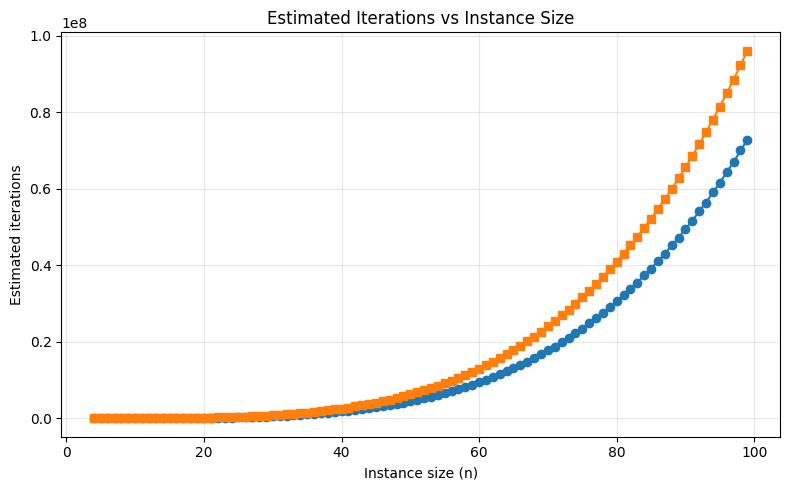

In [20]:
T = 1000
n = 12
def iterations(n):
    return n*sum([(n**4)/(l*n*np.log(n)) for l in range(2, int(n/2)+1)])

#plot for different values of n
n_values = range(4, 100)
iteration_values = [iterations(n) for n in n_values]
alt_iteration_values = [n**4 for n in n_values]
plt.figure(figsize=(8, 5))
plt.plot(n_values, iteration_values, marker="o")
plt.plot(n_values, alt_iteration_values, marker="s", label="n^4")
plt.xlabel("Instance size (n)")
plt.ylabel("Estimated iterations")
plt.title("Estimated Iterations vs Instance Size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

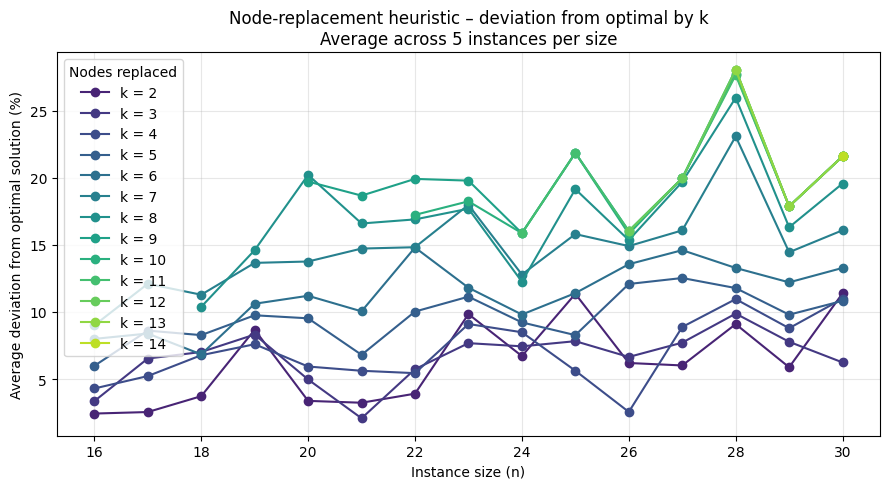

In [11]:
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

with open("results/tsp_results_node_replacement.json", "r", encoding="utf-8") as f:
    nr = json.load(f)

# Normalize keys to ints
nr = {int(n): {int(k): {int(i): v for i, v in inst.items()}
               for k, inst in ks.items()}
      for n, ks in nr.items()}

nr_sizes = sorted(nr.keys())
k_values = sorted({k for n in nr.values() for k in n.keys()})

# Build per-k average deviation from optimal (%) across instances, per size
avg_dev_per_k = {}
for k in k_values:
    avg_dev_per_k[k] = []
    for n in nr_sizes:
        if n not in nr or k not in nr[n] or n not in opt_values:
            avg_dev_per_k[k].append(None)
            continue
        devs = [
            (nr[n][k][i]["val"] / opt_values[n][i] - 1.0) * 100.0
            for i in nr[n][k]
            if i in opt_values[n]
        ]
        avg_dev_per_k[k].append(sum(devs) / len(devs) if devs else None)

# Color map: one distinct colour per k
colors = cm.viridis(np.linspace(0.1, 0.9, len(k_values)))

plt.figure(figsize=(9, 5))
for color, k in zip(colors, k_values):
    ys = avg_dev_per_k[k]
    xs = [n for n, v in zip(nr_sizes, ys) if v is not None]
    ys = [v for v in ys if v is not None]
    plt.plot(xs, ys, marker="o", color=color, label=f"k = {k}")

plt.xlabel("Instance size (n)")
plt.ylabel("Average deviation from optimal solution (%)")
plt.title("Node-replacement heuristic – deviation from optimal by k\nAverage across 5 instances per size")
plt.grid(True, alpha=0.3)
plt.legend(title="Nodes replaced")
plt.tight_layout()
plt.savefig("results/approximation_node_replacement_by_k.pdf")
plt.show()
